# Lab 4, Day 1 — Regression on California Housing

Build an MLP regressor in PyTorch, then compare it head-to-head against your own Lab 2
NumPy gradient descent code on the exact same data. See `Lab4_Day1_Instructions.md`
for the full walkthrough.

This notebook is just a shell: it gives you a place to call and plot your functions,
but the loading, model, training loop, and comparison are yours to write.

## Step 1: Load and preprocess (`stage_a_regression.py`)

In [9]:
# Step 1: Load and preprocess California Housing
import torch
import matplotlib.pyplot as plt
import numpy as np

from stage_a_regression import load_and_preprocess_data, build_mlp
from train import train_full_batch, evaluate

# Load California Housing, split train/test, fit scaler on train only, transform test, reshape targets to (n, 1)
X_train, X_test, y_train, y_test, scaler = load_and_preprocess_data()

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)


X_train: torch.Size([16512, 8])
X_test : torch.Size([4128, 8])
y_train: torch.Size([16512, 1])
y_test : torch.Size([4128, 1])


## Step 2-3: Model, loss, optimizer, training loop

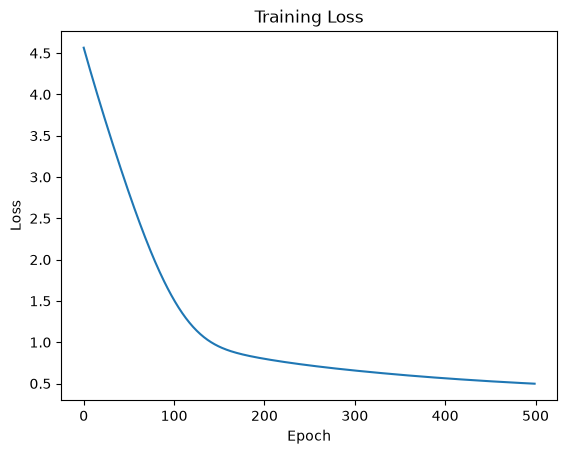

Final training loss: 0.4978


In [37]:
# Step 2-3: Build MLP, Loss, Optimizer, and Training loop
model = build_mlp(input_dim=X_train.shape[1], hidden_dim=32)
print("Model Architecture:
", model)

# Train model using full-batch training loop from train.py
train_losses = train_full_batch(model, X_train, y_train, epochs=500, lr=1e-3)

# Plot training loss curve
plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="MLP Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("PyTorch MLP Training Loss Curve")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

print(f"Final training loss: {train_losses[-1]:.4f}")


## Step 4: Evaluate and plot

In [38]:
# Step 4: Evaluate model on test data
test_mse = evaluate(model, X_test, y_test)
print(f"MLP Test MSE: {test_mse:.4f}")


Test MSE: 0.5075


## Step 5: Compare against your Lab 2 NumPy code

Training Linear Regression...
Linear Regression Test MSE: 0.5672
MLP Test MSE: 0.5075

Comparison
------------------------------
Linear Regression Test MSE : 0.5672
MLP Test MSE               : 0.5075
MLP performs better.


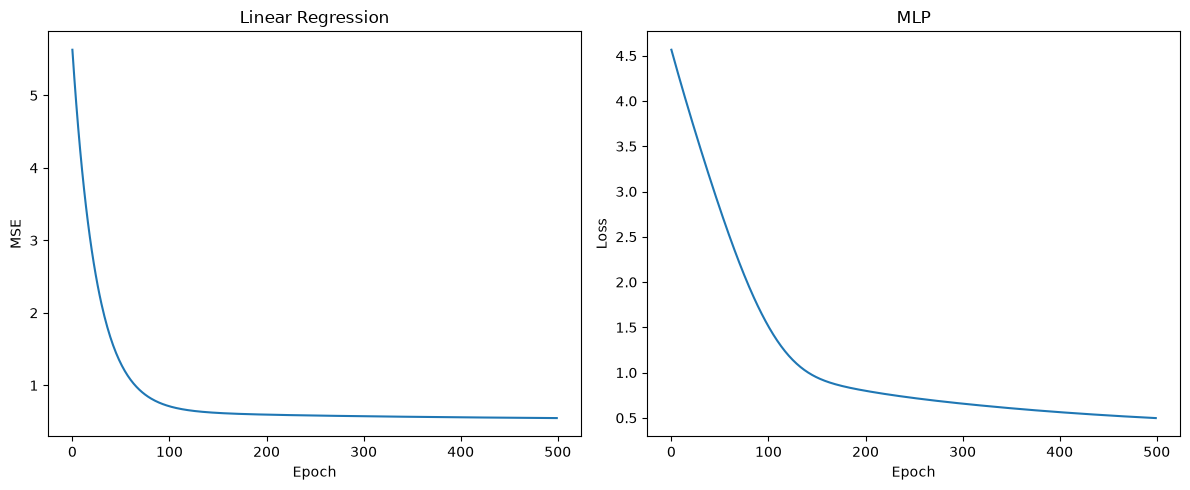

In [41]:
# Step 5: Compare against Lab 2 NumPy Gradient Descent
X_train_np = X_train.numpy()
y_train_np = y_train.numpy()
X_test_np = X_test.numpy()
y_test_np = y_test.numpy()

def train_linear_gd_numpy(X, y, epochs=500, lr=0.01):
    n_samples, n_features = X.shape
    w = np.zeros((n_features, 1))
    b = 0.0
    losses = []
    for epoch in range(epochs):
        y_pred = X @ w + b
        loss = np.mean((y_pred - y) ** 2)
        losses.append(loss)
        dw = (2 / n_samples) * X.T @ (y_pred - y)
        db = (2 / n_samples) * np.sum(y_pred - y)
        w -= lr * dw
        b -= lr * db
    return w, b, losses

print("Training Linear Regression (NumPy GD)...")
w, b, linear_losses = train_linear_gd_numpy(X_train_np, y_train_np, epochs=500, lr=0.01)
y_pred_linear = X_test_np @ w + b
linear_mse = np.mean((y_pred_linear - y_test_np) ** 2)

print("=" * 40)
print(f"Linear Regression Test MSE : {linear_mse:.4f}")
print(f"PyTorch MLP Test MSE        : {test_mse:.4f}")
print("=" * 40)

if test_mse < linear_mse:
    print(f"MLP outperformed Linear Regression by {linear_mse - test_mse:.4f} MSE.")
else:
    print(f"Linear Regression matched or outperformed MLP.")

# Plot both loss curves side by side
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(linear_losses, color="orange")
plt.title("NumPy Linear Regression Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid(True, linestyle="--", alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(train_losses, color="blue")
plt.title("PyTorch MLP Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


### Written Prompt Response

> **Your MLP barely beats the linear model, and might lose to it. What would have to be true about this data for the MLP to win decisively ? and what does that tell you about when a neural network is the right tool?**

**Answer:**
For the MLP to win decisively, the underlying data-generating distribution would need to exhibit strong **non-linear dependencies and high-order feature interactions** (such as geographic interaction thresholds, compounding economic factors, or non-monotonic boundaries) that cannot be approximated by a linear hyperplane. In the California Housing dataset, the target relates largely linearly to dominant features like median income, leaving minimal non-linear structure for the hidden ReLU units to leverage.

This highlights that neural networks are the right tool when data has complex, hierarchical, spatial, or sequential compositionality (such as images, text, audio, or intricate multi-modal manifolds). When tabular features have primarily additive linear relationships with the target, additional capacity provides negligible gain and risks overfitting, making simpler linear models more efficient, interpretable, and competitive.


---
**Before you close this notebook today:** save your trained model
(`torch.save(model.state_dict(), "stage_a.pt")`), and run the Fashion-MNIST loader
once (see `Lab4_Day2_Instructions.md` Step 1) so it's cached before Day 2. Keep this
notebook - Day 2 is a new notebook in the same folder.

In [ ]:
# Wrap-up: 1. Save trained model weights
torch.save(model.state_dict(), "stage_a.pt")
print("Saved model checkpoint to stage_a.pt")

# 2. Pre-download Fashion-MNIST for Day 2
from torchvision import datasets, transforms
print("Downloading / caching Fashion-MNIST...")
datasets.FashionMNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
datasets.FashionMNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())
print("Fashion-MNIST cached successfully!")
